> **Note:** This notebook was completed as part of a university coursework assignment (Exploratory Data Analysis on the Pima Indians Diabetes dataset). It's included here as a record of applied EDA/pandas practice as part of my ML/AI learning journey, not as an original project.


# Assignment: Exploratory Data Analysis of the Diabetes Dataset


## Learning objectives

After completing this assignment, students should be able to:

- load and inspect a dataset;
- detect data-quality problems;
- calculate descriptive statistics;
- create and interpret visualizations;
- examine relationships between variables;
- communicate evidence-based findings.

## Dataset variables

The expected columns are:

- `Pregnancies`
- `Glucose`
- `BloodPressure`
- `SkinThickness`
- `Insulin`
- `BMI`
- `DiabetesPedigreeFunction`
- `Age`
- `Outcome`

`Outcome` is the target: `0` represents a negative diabetes outcome and `1` represents a positive diabetes outcome.



## Setup

Make sure `diabetes.csv` is in the same folder as this notebook before running the cell below.


In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

pd.set_option('display.max_columns', None)
sns.set_theme(style='whitegrid')

df = pd.read_csv('diabetes.csv')  # expects diabetes.csv in the same folder as this notebook


## Section A: Data Loading and Initial Inspection

### Question 1: Preview the dataset 
Display the first 10 rows and the last 5 rows of the dataset. Briefly describe what one row and one column represent.


In [2]:
#First 10 rows
df.head(10)

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1
5,5,116,74,0,0,25.6,0.201,30,0
6,3,78,50,32,88,31.0,0.248,26,1
7,10,115,0,0,0,35.3,0.134,29,0
8,2,197,70,45,543,30.5,0.158,53,1
9,8,125,96,0,0,0.0,0.232,54,1


In [3]:
#Last 5 rows
df.tail(5)

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
763,10,101,76,48,180,32.9,0.171,63,0
764,2,122,70,27,0,36.8,0.340,27,0
765,5,121,72,23,112,26.2,0.245,30,0
766,1,126,60,0,0,30.1,0.349,47,1
767,1,93,70,31,0,30.4,0.315,23,0


One row represents one patient. One column represnets one measured variable across all the patients.

### Question 2: Examine dataset dimensions 
Find the number of rows, number of columns, total number of values, and column names.


In [4]:
# Number of rows and columns
print("Shape (rows, columns):", df.shape)

Shape (rows, columns): (768, 9)


In [5]:
# Number of rows
print("Number of rows:", df.shape[0])

Number of rows: 768


In [6]:
# Number of columns
print("Number of columns:", df.shape[1])

Number of columns: 9


In [7]:
# Total number of values (rows x columns)
print("Total number of values:", df.size)

Total number of values: 6912


In [8]:
# Column names
print("Column names:", list(df.columns))

Column names: ['Pregnancies', 'Glucose', 'BloodPressure', 'SkinThickness', 'Insulin', 'BMI', 'DiabetesPedigreeFunction', 'Age', 'Outcome']


### Question 3: Inspect data types and non-null values 
Use an appropriate Pandas method to display data types, non-null counts, and memory usage. Identify the target variable.


In [9]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 768 entries, 0 to 767
Data columns (total 9 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Pregnancies               768 non-null    int64  
 1   Glucose                   768 non-null    int64  
 2   BloodPressure             768 non-null    int64  
 3   SkinThickness             768 non-null    int64  
 4   Insulin                   768 non-null    int64  
 5   BMI                       768 non-null    float64
 6   DiabetesPedigreeFunction  768 non-null    float64
 7   Age                       768 non-null    int64  
 8   Outcome                   768 non-null    int64  
dtypes: float64(2), int64(7)
memory usage: 54.1 KB


All 9 columns have 768 non-null values, so there are no explicit NaNs. Columns are stored as int64 or float64, which is appropriate. The target variable is Outcome, a binary int64 column (0 = negative, 1 = positive).

### Question 4: Check duplicate records 
Calculate the number of duplicate rows. If duplicates exist, create a cleaned DataFrame without duplicates. Report the shape before and after removal.


In [10]:
# Count duplicate rows
num_duplicates = df.duplicated().sum()
print("Number of duplicate rows:", num_duplicates)

Number of duplicate rows: 0


In [11]:
# Shape before removal
print("Shape before removal:", df.shape)

Shape before removal: (768, 9)


In [12]:
# Create a cleaned copy without duplicates
df_no_duplicates = df.drop_duplicates()

# Shape after removal
print("Shape after removal:", df_no_duplicates.shape)

Shape after removal: (768, 9)


For this dataset, no duplicate records were found, so no rows were removed.

## Section B: Data Quality and Cleaning

### Question 5: Check explicit missing values 
Calculate the number and percentage of `NaN` values in each column. Present the results in a clearly labeled table.


In [13]:
missing_count = df.isnull().sum()
missing_percent = (df.isnull().sum() / len(df)) * 100

missing_summary = pd.DataFrame({
    'Missing Count': missing_count,
    'Missing %': missing_percent.round(2)
})

missing_summary

,Missing Count,Missing %
Pregnancies,0,0.0
Glucose,0,0.0
BloodPressure,0,0.0
SkinThickness,0,0.0
Insulin,0,0.0
BMI,0,0.0
DiabetesPedigreeFunction,0,0.0
Age,0,0.0
Outcome,0,0.0


### Question 6: Investigate invalid zero values
For `Glucose`, `BloodPressure`, `SkinThickness`, `Insulin`, and `BMI`, calculate the count and percentage of zero values. Explain why zero may be invalid for these measurements but valid for `Pregnancies` and `Outcome`.


In [14]:
health_columns = ['Glucose', 'BloodPressure', 'SkinThickness', 'Insulin', 'BMI']

zero_count = (df[health_columns] == 0).sum()
zero_percent = ((df[health_columns] == 0).sum() / len(df)) * 100

zero_summary = pd.DataFrame({
    'Zero Count': zero_count,
    'Zero %': zero_percent.round(2)
})

zero_summary


,Zero Count,Zero %
Glucose,5,0.65
BloodPressure,35,4.56
SkinThickness,227,29.56
Insulin,374,48.70
BMI,11,1.43


For Glucose, BloodPressure, SkinThickness, Insulin, and BMI, a true value of zero is biologically implausible in a living patient. That means you can't have zero blood pressure, zero BMI, etc. So a 0 here almost certainly means the measurement wasn't taken, not that the true value was zero.


For Pregnancies, zero is a completely valid, meaningful value. Many patients genuinely have never been pregnant.


For Outcome, zero is the coded label for "negative diabetes test result". It's categorical, not a physiological measurement, so zero is expected and correct.

### Question 7: Treat invalid zero values
Create a copy called `df_clean`. Replace zeros in the five selected health variables with `NaN`. Then display the missing-value count in `df_clean`.

Do not replace zeros in `Pregnancies` or `Outcome`.


In [15]:
df_clean = df.copy()

health_columns = ['Glucose', 'BloodPressure', 'SkinThickness', 'Insulin', 'BMI']

# Replace 0 with NaN only in the health columns
df_clean[health_columns] = df_clean[health_columns].replace(0, np.nan)

df_clean.isnull().sum()

Pregnancies                   0
Glucose                       5
BloodPressure                35
SkinThickness               227
Insulin                     374
BMI                          11
DiabetesPedigreeFunction      0
Age                           0
Outcome                       0
dtype: int64

After converting invalid zeros to NaN, df_clean now shows missing values in Glucose, BloodPressure, SkinThickness, Insulin, and BMI, matching the counts identified in Question 6. Pregnancies and Outcome remain unaffected.

### Question 8: Impute missing values 
Fill the missing values in `df_clean` using the median of each respective column. Explain why the median can be more suitable than the mean for skewed data or data containing outliers. Confirm that no missing values remain.


In [16]:
health_columns = ['Glucose', 'BloodPressure', 'SkinThickness', 'Insulin', 'BMI']

for col in health_columns:
    median_value = df_clean[col].median()
    df_clean[col] = df_clean[col].fillna(median_value)

# Confirm no missing values remain
df_clean.isnull().sum()

Pregnancies                 0
Glucose                     0
BloodPressure               0
SkinThickness               0
Insulin                     0
BMI                         0
DiabetesPedigreeFunction    0
Age                         0
Outcome                     0
dtype: int64

The mean shifts a lot because of outliers. If a few patients have very high Insulin values, the mean gets pulled up and stops representing a typical patient. The median doesn't have this problem, it's just the middle value, so a few extreme readings don't affect it much. That's why median is a better choice for filling missing values in skewed columns like Insulin and SkinThickness.

## Section C: Descriptive Statistics

### Question 9: Produce a statistical summary
Generate descriptive statistics for all numerical variables. Include count, mean, standard deviation, minimum, quartiles, and maximum. Identify two variables with a wide range.


In [17]:
df_clean.describe()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
count,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000
mean,3.845052,121.656250,72.386719,29.108073,140.671875,32.455208,0.471876,33.240885,0.348958
std,3.369578,30.438286,12.096642,8.791221,86.383060,6.875177,0.331329,11.760232,0.476951
min,0.000000,44.000000,24.000000,7.000000,14.000000,18.200000,0.078000,21.000000,0.000000
25%,1.000000,99.750000,64.000000,25.000000,121.500000,27.500000,0.243750,24.000000,0.000000
50%,3.000000,117.000000,72.000000,29.000000,125.000000,32.300000,0.372500,29.000000,0.000000
75%,6.000000,140.250000,80.000000,32.000000,127.250000,36.600000,0.626250,41.000000,1.000000
max,17.000000,199.000000,122.000000,99.000000,846.000000,67.100000,2.420000,81.000000,1.000000


After cleaning, all 768 rows have complete data. The two variables with the widest range are Insulin (14 to 846) and Age (21 to 81). Insulin's range is unusually large compared to its typical values, which may point to outliers. Age simply reflects the spread of patient ages in the study.

### Question 10: Calculate central tendency and dispersion
For every predictor, calculate the mean, median, standard deviation, variance, range, and interquartile range. Present the results in one summary DataFrame.


In [18]:
predictors = df_clean.drop(columns=['Outcome'])

summary = pd.DataFrame({
    'Mean': predictors.mean(),
    'Median': predictors.median(),
    'Std Dev': predictors.std(),
    'Variance': predictors.var(),
    'Range': predictors.max() - predictors.min(),
    'IQR': predictors.quantile(0.75) - predictors.quantile(0.25)
})

summary.round(2)

,Mean,Median,Std Dev,Variance,Range,IQR
Pregnancies,3.85,3.00,3.37,11.35,17.00,5.00
Glucose,121.66,117.00,30.44,926.49,155.00,40.50
BloodPressure,72.39,72.00,12.10,146.33,98.00,16.00
SkinThickness,29.11,29.00,8.79,77.29,92.00,7.00
Insulin,140.67,125.00,86.38,7462.03,832.00,5.75
BMI,32.46,32.30,6.88,47.27,48.90,9.10
DiabetesPedigreeFunction,0.47,0.37,0.33,0.11,2.34,0.38
Age,33.24,29.00,11.76,138.30,60.00,17.00


Insulin has by far the highest variance (7462) and range (832), but a much smaller IQR (5.75). This means most values are tightly clustered, and the large range/variance is driven by a few extreme outliers. Glucose and BloodPressure are fairly symmetric (mean ≈ median). Insulin and DiabetesPedigreeFunction show the biggest gap between mean and median, suggesting they're right-skewed.

### Question 11: Analyze the target distribution
Calculate the count and percentage of `Outcome = 0` and `Outcome = 1`. State whether the target appears balanced or imbalanced.


In [19]:
outcome_count = df_clean['Outcome'].value_counts()
outcome_percent = df_clean['Outcome'].value_counts(normalize=True) * 100

outcome_summary = pd.DataFrame({
    'Count': outcome_count,
    'Percentage': outcome_percent.round(2)
})

outcome_summary

,Count,Percentage
Outcome,,
0,500,65.1
1,268,34.9


Outcome = 0 (negative): 500 patients (65.1%). Outcome = 1 (positive): 268 patients (34.9%). The target is imbalanced and negative cases are nearly double the positive cases.

### Question 12: Compare groups by outcome
Group the cleaned data by `Outcome` and calculate the mean and median of all predictor variables. Identify the three variables showing the most noticeable differences between the groups.


In [20]:
group_summary = df_clean.groupby('Outcome').agg(['mean', 'median'])
group_summary.round(2)

Pregnancies        Glucose        BloodPressure        SkinThickness  \
               mean median    mean median          mean median          mean   
Outcome                                                                        
0              3.30    2.0  110.68  107.5         70.92   72.0         27.73   
1              4.87    4.0  142.13  140.0         75.12   74.0         31.69   

               Insulin           BMI        DiabetesPedigreeFunction         \
        median    mean median   mean median                     mean median   
Outcome                                                                       
0         29.0  127.79  125.0  30.89  30.40                     0.43   0.34   
1         29.0  164.70  125.0  35.38  34.25                     0.55   0.45   

           Age         
          mean median  
Outcome                
0        31.19   27.0  
1        37.07   36.0

By percentage difference from group 0 to group 1: Pregnancies (+47.6%), Insulin (+28.9%), and Glucose (+28.4%) show the largest relative differences between the two outcome groups. Diabetic patients (Outcome=1) tend to have higher values across almost every predictor, most notably higher glucose and insulin levels. This is consistent with the biology of diabetes, though this alone doesn't prove causation.

## Section D: Univariate Visualization

### Question 13: Plot numerical distributions
Create histograms for all predictor variables. Use suitable figure dimensions and titles. Identify at least two variables that appear positively skewed.


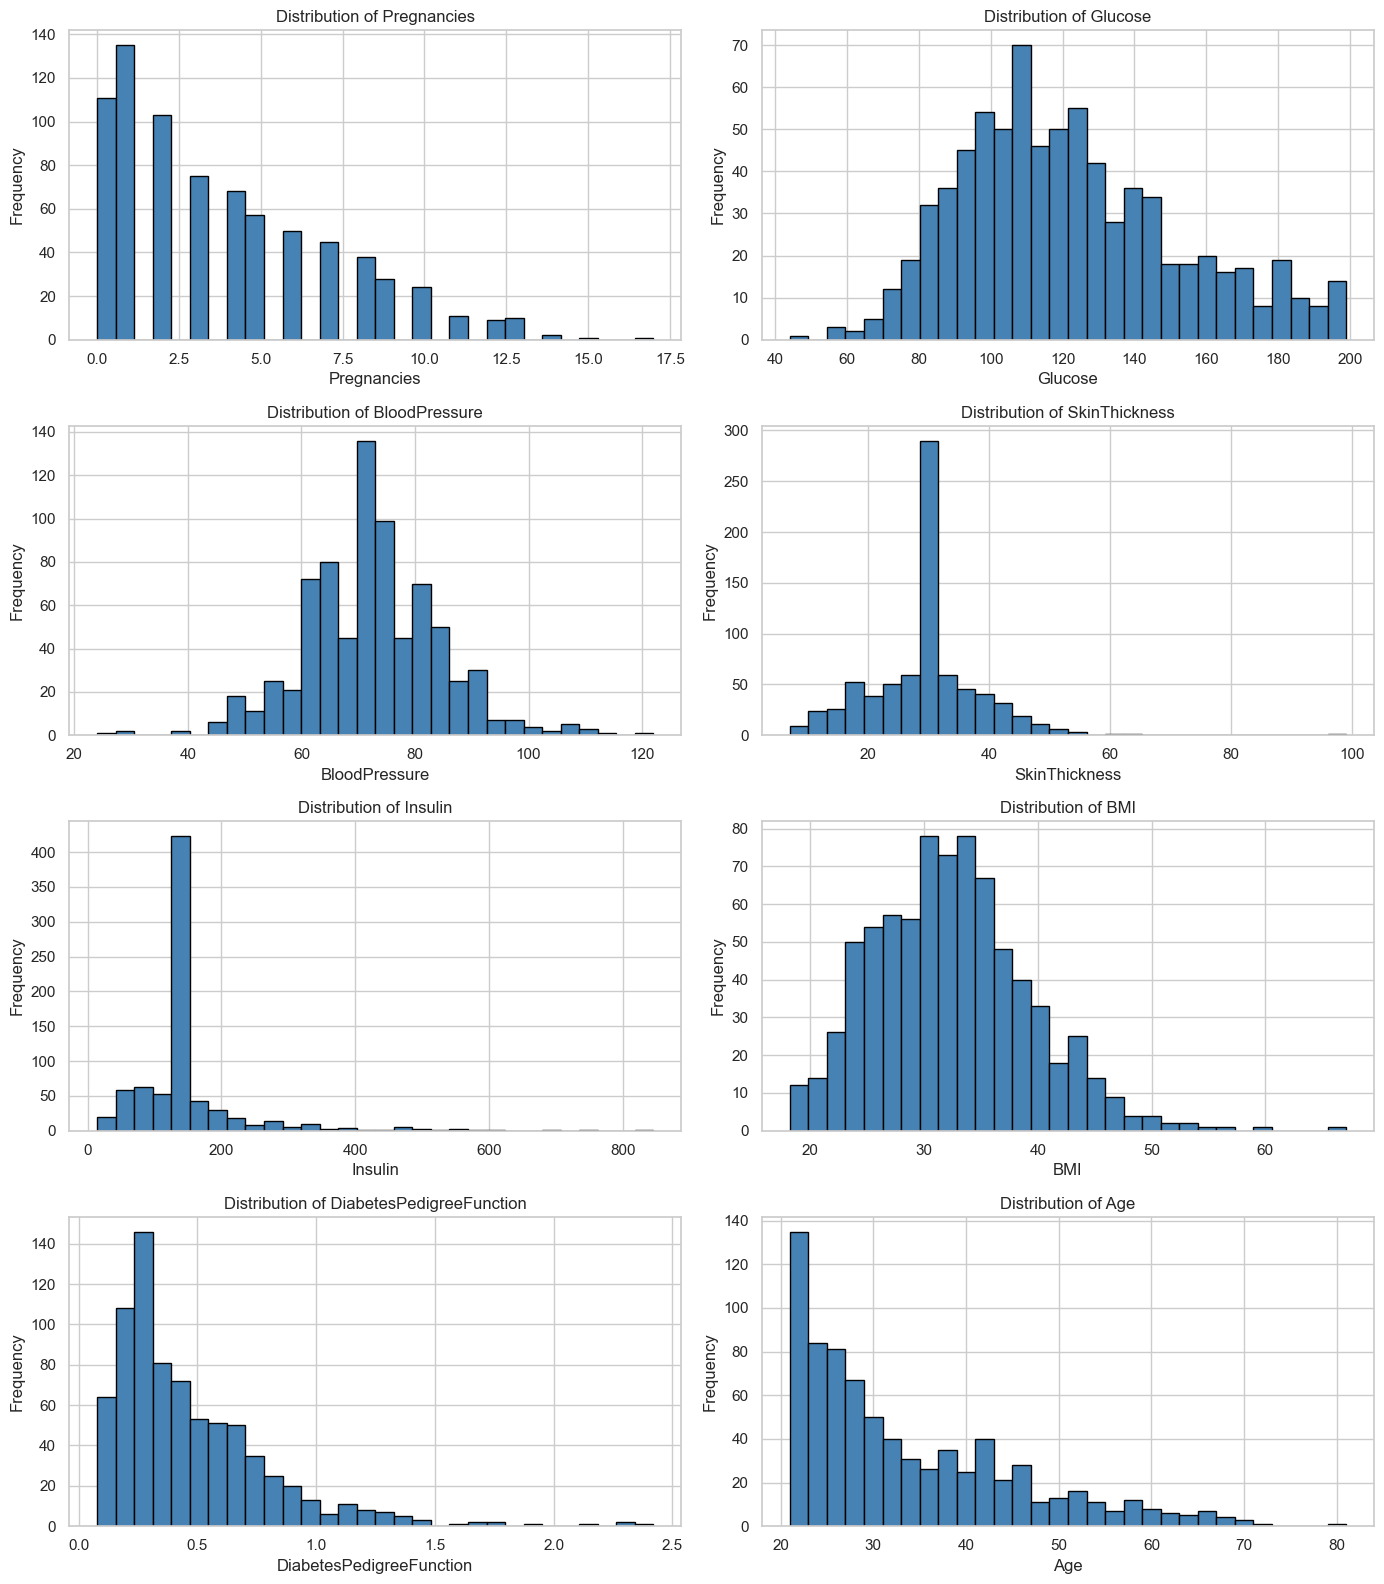

In [21]:
predictors = df_clean.drop(columns=['Outcome']).columns

fig, axes = plt.subplots(4, 2, figsize=(14, 16))
axes = axes.flatten()

for i, col in enumerate(predictors):
    axes[i].hist(df_clean[col], bins=30, color='steelblue', edgecolor='black')
    axes[i].set_title(f'Distribution of {col}')
    axes[i].set_xlabel(col)
    axes[i].set_ylabel('Frequency')

plt.tight_layout()
plt.show()

Insulin and DiabetesPedigreeFunction are the most positively skewed (long tail to the right), confirming what the skewness numbers showed earlier. Age and Pregnancies are also right-skewed. Most patients are younger with fewer pregnancies, with a tail of older/higher values. Glucose, BMI, and BloodPressure look closer to a bell shape.

### Question 14: Detect possible outliers
Create box plots for all predictor variables. Identify variables with visible potential outliers. Explain why a point outside a box-plot whisker should not automatically be deleted.


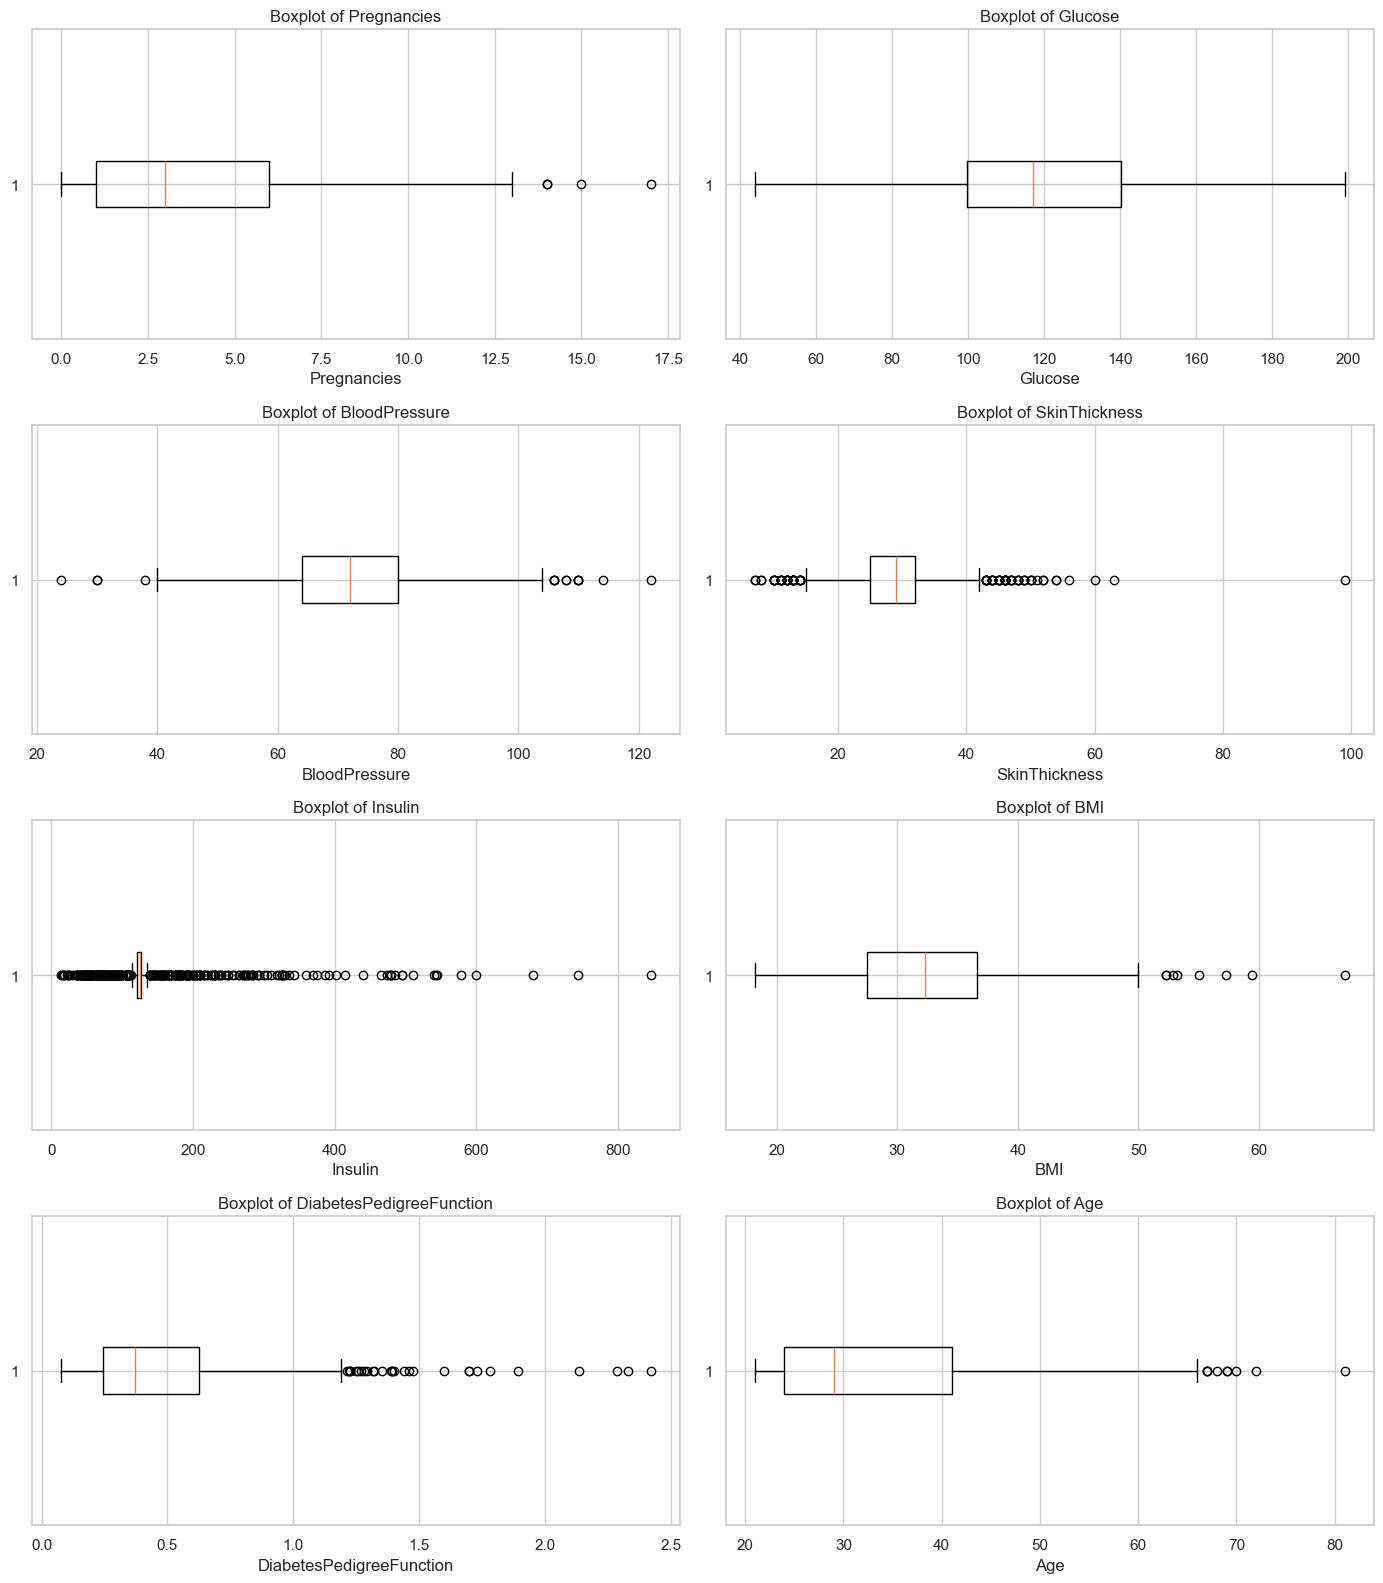

In [22]:
predictors = df_clean.drop(columns=['Outcome']).columns

fig, axes = plt.subplots(4, 2, figsize=(14, 16))
axes = axes.flatten()

for i, col in enumerate(predictors):
    axes[i].boxplot(df_clean[col], vert=False)
    axes[i].set_title(f'Boxplot of {col}')
    axes[i].set_xlabel(col)

plt.tight_layout()
plt.show()

A point beyond the whisker just means it's unusual compared to the rest of the sample. It doesn't mean it's wrong. It could be a real patient with a genuinely extreme value, like unusually high insulin due to an actual medical condition. If we delete it without checking, we might be throwing away real information and making the analysis less accurate, which matters a lot in health data. So before removing anything, we should first check if it makes sense, not just delete it because it's far from the others.

### Question 15: Visualize the outcome variable
Create a count plot for `Outcome`. Replace numeric display labels with meaningful labels such as `Negative` and `Positive`. Add the count above each bar.


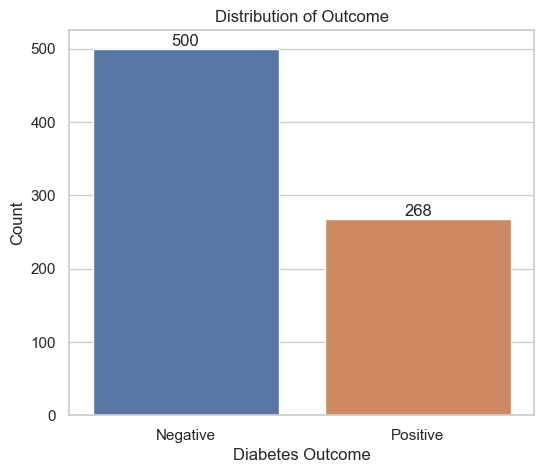

In [23]:
fig, ax = plt.subplots(figsize=(6, 5))
ax = sns.countplot(data=df_clean, x='Outcome', hue='Outcome',
                    palette=['#4C72B0', '#DD8452'], legend=False)

ax.set_xticks([0, 1])
ax.set_xticklabels(['Negative', 'Positive'])
ax.set_xlabel('Diabetes Outcome')
ax.set_ylabel('Count')
ax.set_title('Distribution of Outcome')

for container in ax.containers:
    ax.bar_label(container)

plt.show()

The count plot confirms the imbalance already identified: 500 patients (65.1%) with a negative outcome versus 268 (34.9%) with a positive outcome. Negative cases are roughly 1.9x more common than positive cases.

## Section E: Relationships Between Variables

### Question 16: Compare glucose by outcome
Create a box plot comparing `Glucose` for the two outcome groups. Compare the median, spread, and possible outliers. Write at least two observations.


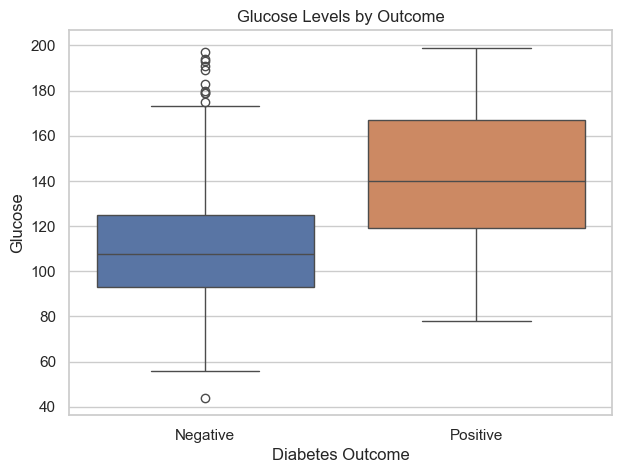

In [24]:
fig, ax = plt.subplots(figsize=(7, 5))
sns.boxplot(data=df_clean, x='Outcome', y='Glucose', hue='Outcome',
            palette=['#4C72B0', '#DD8452'], legend=False)
ax.set_xticks([0, 1])
ax.set_xticklabels(['Negative', 'Positive'])
ax.set_xlabel('Diabetes Outcome')
ax.set_ylabel('Glucose')
ax.set_title('Glucose Levels by Outcome')
plt.show()

The median glucose is much higher for positive outcomes (140) than negative outcomes (107.5). About a 30-point gap, confirming glucose is strongly associated with diabetes outcome.

The positive group also has a wider spread (std ≈ 29.6 vs 24.7) and a higher 25th percentile (119 vs 93), meaning even "lower" glucose readings in the positive group are still elevated compared to most negative-outcome patients. There's some overlap between the two boxes, but overall clear separation.

### Question 17: Examine glucose and BMI together
Create a scatter plot with `Glucose` on the x-axis, `BMI` on the y-axis, and `Outcome` represented by color. Describe any visible separation, overlap, clusters, or unusual observations.


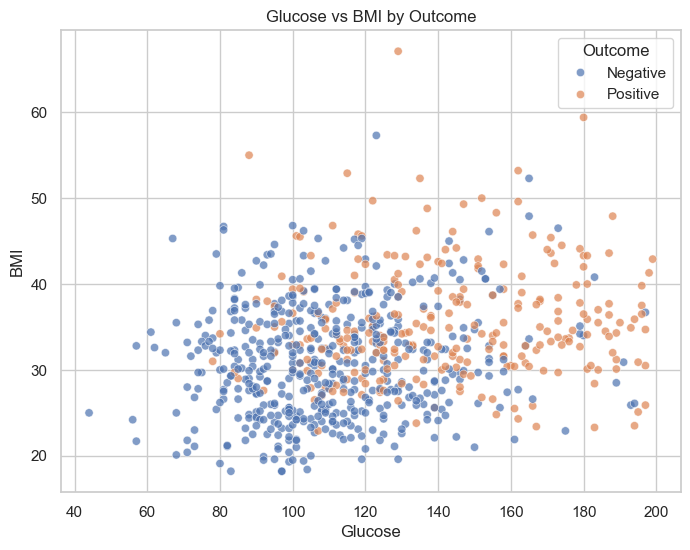

In [25]:
fig, ax = plt.subplots(figsize=(8, 6))
sns.scatterplot(data=df_clean, x='Glucose', y='BMI', hue='Outcome',
                 palette={0: '#4C72B0', 1: '#DD8452'}, alpha=0.7, ax=ax)
ax.set_title('Glucose vs BMI by Outcome')
handles, labels = ax.get_legend_handles_labels()
ax.legend(handles, ['Negative', 'Positive'], title='Outcome')
plt.show()

Positive-outcome points (orange) tend to cluster where glucose and BMI are both high, while negative-outcome points (blue) cluster where both are low. For example, out of patients with low glucose and low BMI, 90 were negative and only 3 were positive. But out of patients with high glucose and high BMI, 63 were positive and only 19 were negative. Still, the two groups overlap a lot in the middle of the plot, so there's no clean line separating them. Glucose and BMI together give useful signal, but not a perfect split.

### Question 18: Create and interpret a correlation heatmap
Calculate the Pearson correlation matrix and display an annotated heatmap. Identify:

1. the predictor most strongly correlated with `Outcome`;
2. the strongest positive correlation between two predictors;
3. whether any strong negative correlations are present.

Remember that correlation does not establish causation.


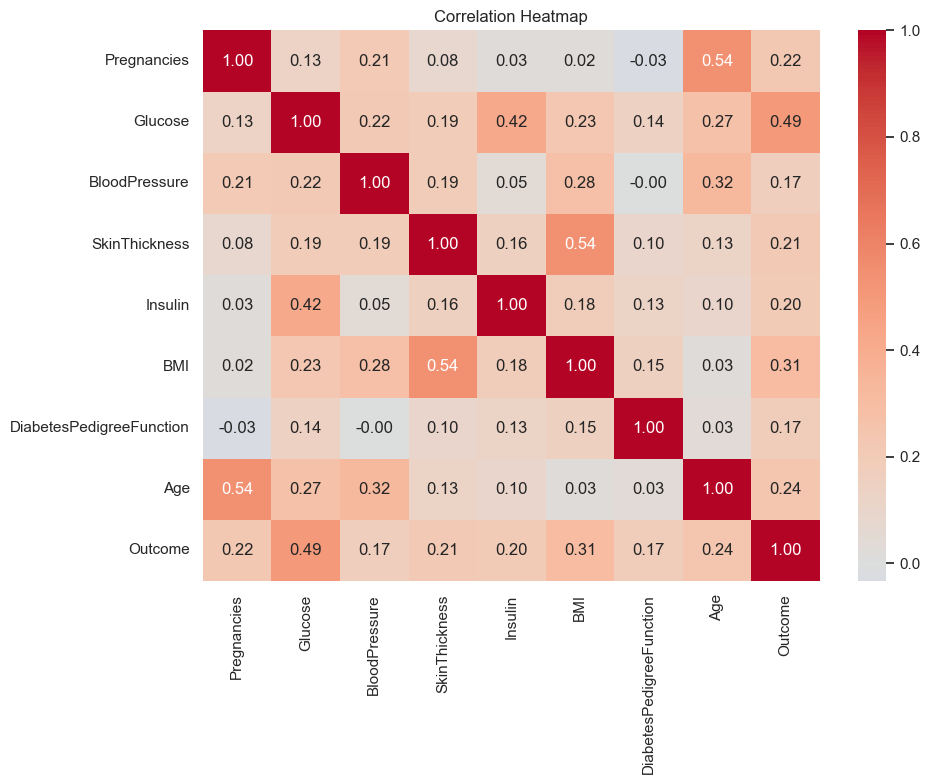

In [26]:
corr_matrix = df_clean.corr()

fig, ax = plt.subplots(figsize=(10, 8))
sns.heatmap(corr_matrix, annot=True, fmt='.2f', cmap='coolwarm', center=0, ax=ax)
ax.set_title('Correlation Heatmap')
plt.tight_layout()
plt.show()

Glucose has the strongest correlation with Outcome (r ≈ 0.49), making it the most related single variable.

Among the predictors themselves, Pregnancies and Age have the strongest correlation (r ≈ 0.54), followed closely by SkinThickness and BMI (also ≈ 0.54). Both make sense: more pregnancies usually happen at older ages, and higher BMI usually means more body fat, which relates to skin thickness.

There are no strong negative correlations in this dataset. Everything is either weakly positive or close to zero.

## Section F: Outliers and Final Interpretation

### Question 19: Identify outliers using the IQR method 
For each predictor, calculate the lower and upper outlier bounds using:

\[
IQR = Q_3-Q_1
\]

\[
	ext{Lower bound}=Q_1-1.5(IQR)
\]

\[
	ext{Upper bound}=Q_3+1.5(IQR)
\]

Create a table showing the number and percentage of potential outliers in each variable. Do not remove the outliers automatically.


In [27]:
predictors = df_clean.drop(columns=['Outcome']).columns

outlier_summary = {}
for col in predictors:
    Q1 = df_clean[col].quantile(0.25)
    Q3 = df_clean[col].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR

    outliers = df_clean[(df_clean[col] < lower_bound) | (df_clean[col] > upper_bound)]
    outlier_summary[col] = {
        'Lower Bound': round(lower_bound, 2),
        'Upper Bound': round(upper_bound, 2),
        'Outlier Count': len(outliers),
        'Outlier %': round(len(outliers) / len(df_clean) * 100, 2)
    }

outlier_df = pd.DataFrame(outlier_summary).T
outlier_df

,Lower Bound,Upper Bound,Outlier Count,Outlier %
Pregnancies,-6.50,13.50,4.0,0.52
Glucose,39.00,201.00,0.0,0.00
BloodPressure,40.00,104.00,14.0,1.82
SkinThickness,14.50,42.50,87.0,11.33
Insulin,112.88,135.88,346.0,45.05
BMI,13.85,50.25,8.0,1.04
DiabetesPedigreeFunction,-0.33,1.20,29.0,3.78
Age,-1.50,66.50,9.0,1.17


Insulin has the most flagged outliers by far (346, about 45%). But this is partly caused by the way we filled missing values. Since so many missing Insulin values were replaced with the same median, the middle 50% of the data got squeezed tighter, so the IQR became smaller and more points ended up falling outside the bounds. SkinThickness (11.3%) and DiabetesPedigreeFunction (3.8%) also have a fair number of outliers, while Glucose has almost none. As the question asked, we didn't remove any outliers here, just counted them.

### Question 20: Write the EDA conclusion
Write a conclusion of approximately **200 to 300 words**. Include:

- dataset dimensions;
- important data-quality issues;
- outcome distribution;
- notable distribution patterns;
- important group differences;
- strongest correlations;
- possible outliers;
- three variables that may be useful in later predictive modeling;
- at least two limitations of the analysis.

Every major statement should be supported by numerical or visual evidence from the notebook. Do not claim that the analysis proves causation or provides a medical diagnosis.


This analysis looked at 768 patient records with 9 variables: 8 predictors and one target, Outcome. There were no missing values in the raw data, but five columns (Glucose, BloodPressure, SkinThickness, Insulin, and BMI) had zeros that don't make biological sense, especially Insulin and SkinThickness. These zeros were treated as missing and filled in using each column's median.

The target is imbalanced: 500 patients (65.1%) tested negative and 268 (34.9%) tested positive. Some predictors, especially Insulin and DiabetesPedigreeFunction, were heavily right-skewed. When comparing the two outcome groups, Pregnancies, Insulin, and Glucose showed the biggest differences, with positive-outcome patients generally having higher values. Glucose showed the clearest gap (median 140 vs 107.5) and had the strongest correlation with Outcome (r ≈ 0.49). The strongest correlations between predictors were Pregnancies and Age, and SkinThickness and BMI (both around 0.54). There were no strong negative correlations.

Using the IQR method, Insulin had the highest percentage of outliers (about 45%), though this is partly due to how imputation squeezed its IQR. SkinThickness and DiabetesPedigreeFunction also had a fair number of outliers.

Glucose, BMI, and Insulin look like the most useful predictors for future modeling based on their relationship with Outcome.

Limitations: filling missing values with the median may hide the real variability in the data and make outlier counts look bigger than they should. The class imbalance could also make future models biased toward predicting the negative class. These are just associations, not proof of cause and effect, and this is not a medical diagnosis.